In [ ]:
!pip install qiskit qiskit-aer qiskit-ibm-runtime

## superdense coding


Figure(998.442x284.278)


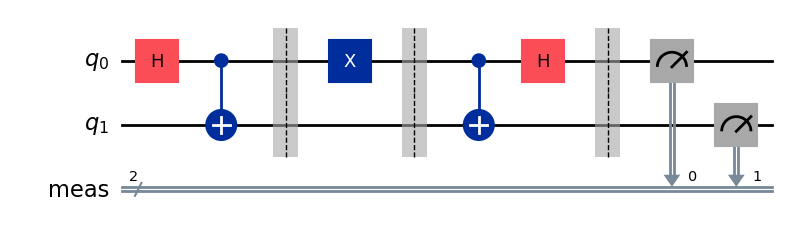

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
%matplotlib inline

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)

qc.barrier()

msg='01'
qubit=0
if msg=='00':
    pass
elif msg=='01':
    qc.x(qubit)
elif msg=='10':
    qc.z(qubit)
elif msg=='11':
    qc.x(qubit)
    qc.z(qubit)

qc.barrier()

qc.cx(0,1)
qc.h(0)
qc.measure_all()
print(qc.draw(output='mpl'))

## teleportation


In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
import numpy as np
%matplotlib inline

def create_teleportation_circuit():
    qr = QuantumRegister(3, name="q")
    crz = ClassicalRegister(1, name="crz") # For Alice's Z measurement
    crx = ClassicalRegister(1, name="crx") # For Alice's X measurement
    qc = QuantumCircuit(qr, crz, crx)

    # Create state |psi> to teleport
    qc.rx(np.pi/3, 0) 
    qc.barrier()

    # Create Bell Pair
    qc.h(1)
    qc.cx(1, 2)
    qc.barrier()

    # Alice's Bell-state measurement
    qc.cx(0, 1)
    qc.h(0)
    qc.barrier()
    qc.measure(0, 0) # crz
    qc.measure(1, 1) # crx
    qc.barrier()

    # Bob's Corrections
    with qc.if_test((crx, 1)):   # if alice's second bit is 1
        qc.x(2)                  # x gate on bob's qubit
    with qc.if_test((crz, 1)):
        qc.z(2)
    
    return qc

qc = create_teleportation_circuit()
print(qc.draw('mpl'))

backend = AerSimulator(method='statevector')
qc.save_statevector()
out_state = backend.run(qc).result().get_statevector()

print("\nTeleportation complete. The statevector has been transferred to qubit 2.")

## coin game


when flip = True, result = {'0': 1000}
when flip = False, result = {'0': 1000}
Figure(687.119x200.667)


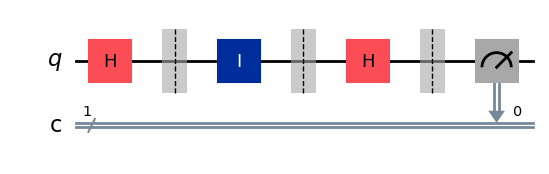

In [2]:
from qiskit import QuantumCircuit  # noqa: F811
from qiskit_aer import AerSimulator
%matplotlib inline

def game(flip):
    qc = QuantumCircuit(1,1)

    qc.h(0)
    qc.barrier()

    if flip:
        qc.x(0)
    else:
        qc.id(0)
        # pass
    qc.barrier()

    qc.h(0)
    qc.barrier()

    qc.measure(0,0)
    return qc

backend = AerSimulator()
for f in [True, False]:
    qc = game(f)
    counts = backend.run(qc, shots=1000).result().get_counts()
    print(f'when flip = {f}, result = {counts}')

print(qc.draw(output='mpl'))